# Classification with Decision Trees and KNN

You will be using the loan dataset. Download the dataset and place the CSV file in your working directory.

### Import necessary libraries

In [1]:
# Data manipulation and analysis
import pandas as pd

# Machine learning models and evaluation
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
from sklearn import tree
from matplotlib.colors import ListedColormap
from sklearn.inspection import DecisionBoundaryDisplay

### Question 1: Decision Tree Classifiers

Step 1: Load the dataset

In [28]:
df = pd.read_csv("Module3_Homework2_dataset.csv")

Step 2: Preprocess the dataset
- Using the *df.isnull().sum()* function, identify columns with missing values. In this dataset, the columns RankSeason, RankPlayoffs, OOBP, and OSLG have a majority of their values missing. For this exercise, drop these columns from the dataset to simplify the analysis.
- Encode categorical variables using label encoding.

{accuracy: 3}

In [29]:
# Handle missing values
df.isnull().sum()


Age         0
Salary      0
Has_Loan    0
dtype: int64

In [30]:
# Scale features using StandardScaler()
scaler = StandardScaler()

# Define features and target
features = ['Age', 'Salary']
x = df[features].values

x_scaled = scaler.fit_transform(x)

df_scaled = pd.DataFrame(x_scaled, columns=features)
df_final = pd.concat([df_scaled, df[['Has_Loan']]], axis=1)

Step 3: Split the dataset into training and testing sets

{accuracy: 2}

In [31]:
X = df[['Age', 'Salary']].values
y = df['Has_Loan'].values

# Split the dataset using test_size = 0.2 and random_state = 42

In [32]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, 
    y, 
    test_size=0.2, 
    random_state=42
    )

Step 4: Train Decision Tree classifiers with different max_depth values

{accuracy: 4}

In [34]:
# Define max_depth values
max_depth_values = [3, 5, 7, 10]

# Train and evaluate Decision Tree classifiers
for max_depth in max_depth_values:
    model = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    # Fit the model using the training data

    model.fit(X_train, y_train)

    # Predict the labels for the training and the testing data

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate the error on the training and the testing data

    train_error = 1 - accuracy_score(y_train, y_train_pred)
    test_error = 1 - accuracy_score(y_test, y_test_pred)

    # Print the results
    print(f"{max_depth:<10} | {train_error:<15.4f} | {test_error:<15.4f}")

3          | 0.2750          | 0.4000         
5          | 0.2000          | 0.4000         
7          | 0.1500          | 0.4000         
10         | 0.1250          | 0.4000         


Step 5: Reduce dimensionality using PCA and visualize decision boundaries

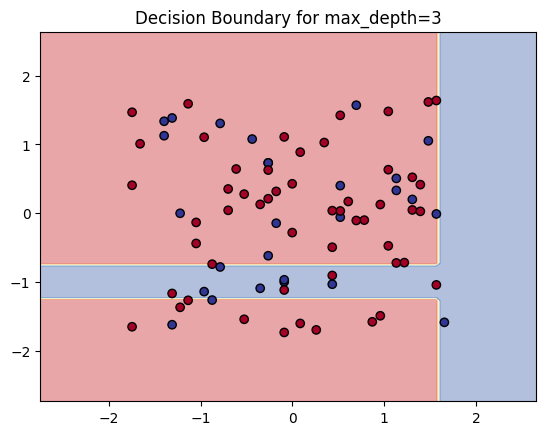

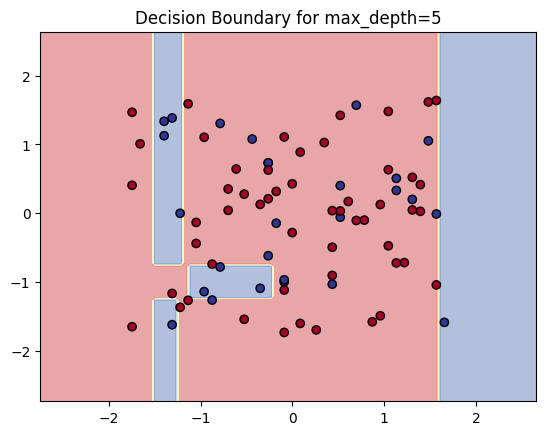

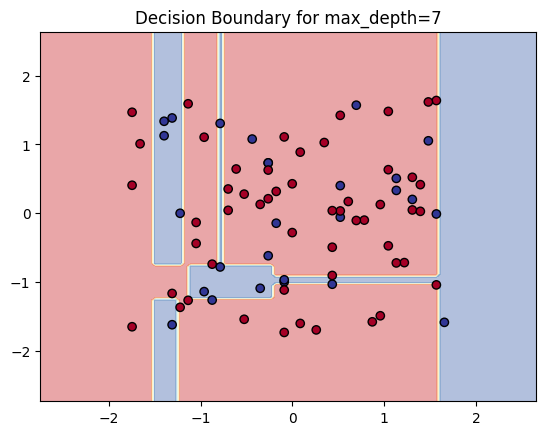

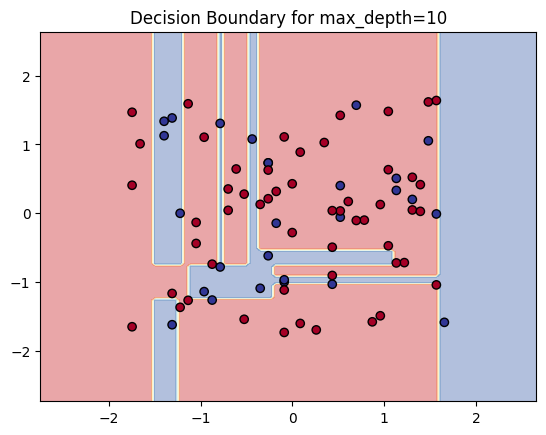

In [35]:
# Visualize Decision Tree classifiers with different max_depth values
for max_depth in max_depth_values:
    model = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    model.fit(X_train, y_train)

    # Plot the decision boundary using DecisionBoundaryDisplay
    DecisionBoundaryDisplay.from_estimator(model, X_train, response_method="predict", cmap=plt.cm.RdYlBu, alpha=0.4)
    
    # CORRECTED LINE: Removed .iloc, used direct numpy indexing [:, 0]
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor='k', cmap=plt.cm.RdYlBu)
    
    plt.title(f'Decision Boundary for max_depth={max_depth}')
    plt.show()

In [36]:
X_train[:,0]

array([ 1.30572443e+00, -2.63236835e-01, -8.89078050e-02, -2.63236835e-01,
        5.21243798e-01, -1.22204650e+00,  5.21243798e-01,  4.34079283e-01,
       -1.74329029e-03,  1.65438249e+00, -7.86223923e-01, -2.63236835e-01,
       -5.24730379e-01,  1.13139540e+00,  4.34079283e-01,  1.56721797e+00,
        8.69901857e-01, -1.30921101e+00,  7.82737342e-01, -1.39637553e+00,
        1.13139540e+00,  4.34079283e-01,  1.48005346e+00, -1.39637553e+00,
        1.21855992e+00, -5.24730379e-01, -1.30921101e+00, -2.63236835e-01,
       -8.73388438e-01, -8.89078050e-02,  3.46914769e-01,  1.56721797e+00,
       -6.99059408e-01,  1.04423089e+00,  2.59750254e-01, -1.76072320e-01,
       -1.74329029e-03,  5.21243798e-01, -1.13488198e+00,  8.54212244e-02,
       -3.50401349e-01, -9.60552952e-01, -3.50401349e-01, -1.13488198e+00,
        8.54212244e-02, -1.04771747e+00, -1.04771747e+00,  1.30572443e+00,
        1.04423089e+00,  6.95572828e-01,  6.95572828e-01,  1.56721797e+00,
        6.08408313e-01, -

Step 6: Comment on the complexity of each model based on decision boundaries using a markdown cell

{reasoning: 2}

the more the depth, the more classificantion is has; however, it has also become more noisy. To select cleaner output, I recommend using max depth of 3 or 5, ie, on the shoaddlower side.

### Question 2: K-Nearest Neighbors (KNN) Classifiers

Step 1: Train KNN classifiers with different n_neighbors values

{accuracy: 3}

In [48]:
# Define n_neighbors values
n_neighbors_values = [3, 5, 7, 10]

# Train and evaluate KNN classifiers
for n_neighbors in n_neighbors_values:
    model = KNeighborsClassifier(n_neighbors=n_neighbors)
    # Fit the model using the training data

    model.fit(X_train, y_train)

    # Predict the labels for the training and the testing data

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate the error on the training and the testing data

    train_error = 1 - accuracy_score(y_train, y_train_pred)
    test_error = 1 - accuracy_score(y_test, y_test_pred)

    # Print the results
    print(f"{n_neighbors:<15} | {train_error:<15.4f} | {test_error:<15.4f}")

3               | 0.2250          | 0.4000         
5               | 0.3000          | 0.4000         
7               | 0.2875          | 0.5000         
10              | 0.3000          | 0.4000         


Step 2: Visualize decision boundaries

{accuracy: 2}

In [49]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

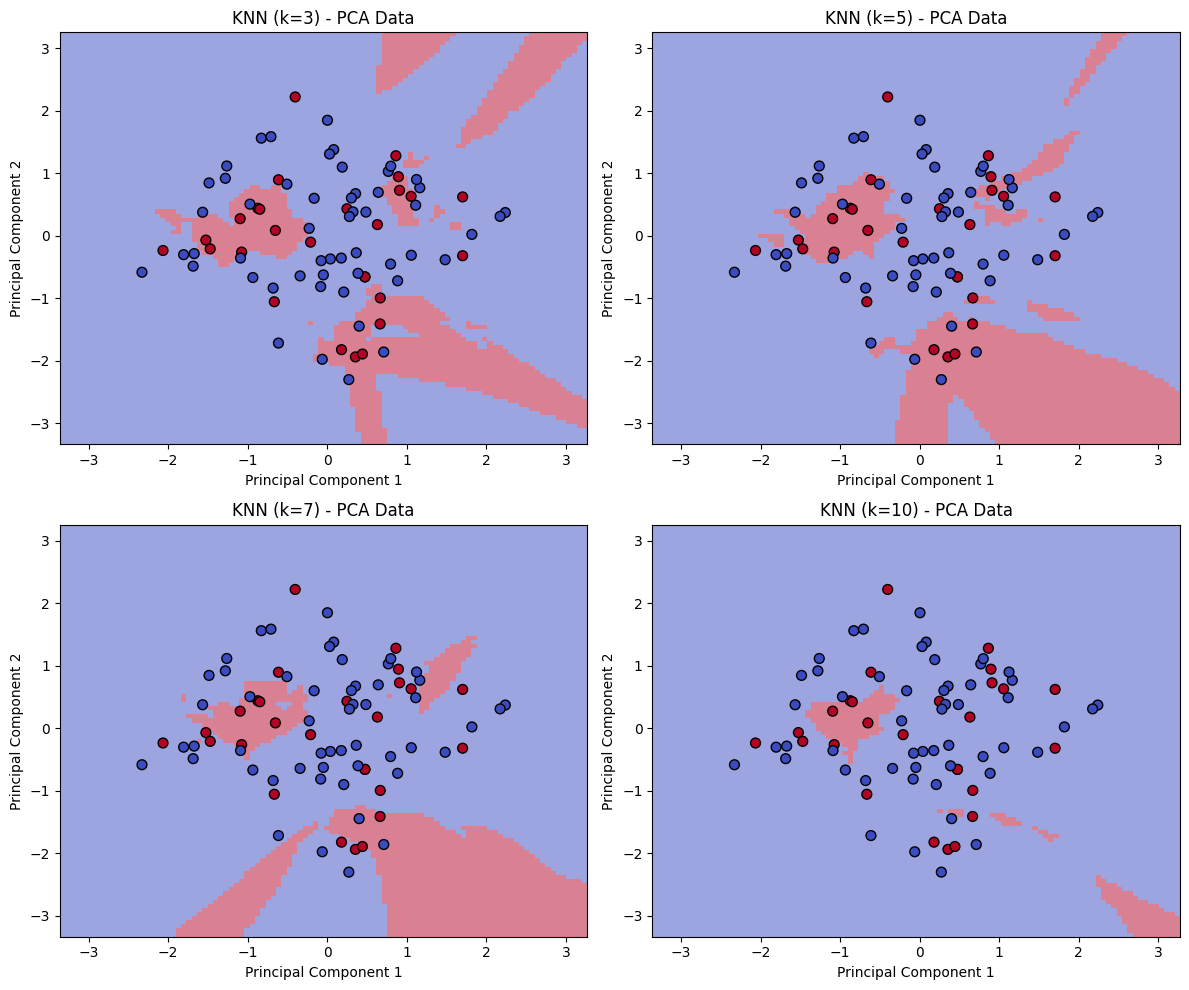

In [50]:
n_neighbors_values = [3, 5, 7, 10]

# Apply PCA to the scaled training data
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Visualize KNN classifiers with different n_neighbors values using the PCA reduced X train
for i, n_neighbors in enumerate(n_neighbors_values):
    # Initialize and train the model on PCA data
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(X_train_pca, y_train)
    
    ax = axes[i]
    
    # Plot the decision boundary using DecisionBoundaryDisplay
    DecisionBoundaryDisplay.from_estimator(
        knn,
        X_train_pca,
        ax=ax,
        response_method="predict",
        plot_method="pcolormesh",
        shading="auto",
        cmap="coolwarm",
        alpha=0.5
    )
    
    # Scatter plot the PCA-transformed training points
    ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap="coolwarm", edgecolors="k", s=50)
    
    # Set titles and labels
    ax.set_title(f"KNN (k={n_neighbors}) - PCA Data")
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")

plt.tight_layout()
plt.show()

Step 3: Comment on the complexity of each model based on decision boundaries using a markdown cell

{reasoning: 2}

the KNN, with increasing K produces fine classification. However, k=9 runs into the problem of overfitting. Looking at the graphs above, we can see that k=5 or 7 produce a balanced output.

### Question 3: Decision Trees with Varying Depths

Step 1: Fit Decision Tree classifiers with max_depth values from 1 to 25

{accuracy: 2}

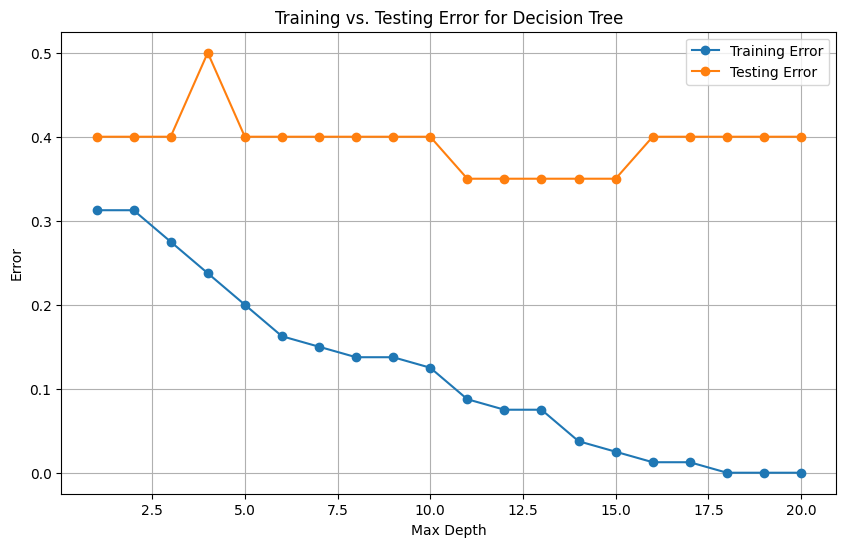

In [51]:
max_depth_range = max_depth_range = range(1, 21)
train_errors = []
test_errors = []

for max_depth in max_depth_range:
    # Initialize the model
    model = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    
    # Fit the model
    model.fit(X_train, y_train)
    
    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate errors
    train_errors.append(1 - accuracy_score(y_train, y_train_pred))
    test_errors.append(1 - accuracy_score(y_test, y_test_pred))

# Optional: Plot the results to visualize overfitting
plt.figure(figsize=(10, 6))
plt.plot(max_depth_range, train_errors, label='Training Error', marker='o')
plt.plot(max_depth_range, test_errors, label='Testing Error', marker='o')
plt.xlabel('Max Depth')
plt.ylabel('Error')
plt.title('Training vs. Testing Error for Decision Tree')
plt.legend()
plt.grid(True)
plt.show()


Step 2: Plot two curves for training and testing errors with max_depth on the x-axis and error on the y-axis.

{accuracy: 2}

In [ ]:
See above code and graph output

Step 3: Identify and explain the best depth using a markdown cell

{reasoning: 1}

I would argue that depth of 5 would produce the best output, given the error rate stay the same in more depth; and it is not too overcrowding at this depth.

### Question 4: Cross-Validation for Decision Trees

Use cross-validation to verify optimal depth and report the cross-validation scores and the mean score.

{accuracy: 2}

In [52]:
# Find the optimal depth corresponding to the minimum test error
optimal_depth = max_depth_range[np.argmin(test_errors)]

print(f"Optimal Depth: {optimal_depth}")

# Initialize the model with the optimal parameters
best_model = DecisionTreeClassifier(max_depth=optimal_depth, random_state=42)

# Evaluate with cross-validation and report the cross-validation scores and the mean score.
# We use X_train and y_train for cross-validation
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5)
cv_mean = cv_scores.mean()

# Print Results
print("Cross-validation scores:", cv_scores)
print(f"Mean cross-validation score: {cv_mean:.4f}")

Optimal Depth: 11
Cross-validation scores: [0.5    0.625  0.375  0.75   0.6875]
Mean cross-validation score: 0.5875
